In [ ]:
import os, matplotlib, matplotlib.pyplot as plt
OUT_DIR = "/web/omunkombwe/public_html"
os.makedirs(OUT_DIR, exist_ok=True)
if not getattr(matplotlib, "_autosave_patched", False):
    _old_fig_savefig = matplotlib.figure.Figure.savefig
    def _savefig_prefix(self, fname, *args, **kwargs):
        if isinstance(fname, str) and not os.path.isabs(fname):
            fname = os.path.join(OUT_DIR, fname)
            os.makedirs(os.path.dirname(fname) or OUT_DIR, exist_ok=True)
        return _old_fig_savefig(self, fname, *args, **kwargs)
    matplotlib.figure.Figure.savefig = _savefig_prefix
    _old_plt_savefig = plt.savefig
    def _plt_savefig(fname, *args, **kwargs):
        if isinstance(fname, str) and not os.path.isabs(fname):
            fname = os.path.join(OUT_DIR, fname)
            os.makedirs(os.path.dirname(fname) or OUT_DIR, exist_ok=True)
        return _old_plt_savefig(fname, *args, **kwargs)
    plt.savefig = _plt_savefig
    matplotlib._autosave_patched = True


In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import vector

In [2]:
file = uproot.open("/ceph/omunkombwe/ee_mumu11.root")
tree = file["events"]

In [3]:
pdg = tree['MCParticles.PDG'].array()
status = tree["MCParticles.generatorStatus"].array()
px = tree["MCParticles.momentum.x"].array()
py = tree["MCParticles.momentum.y"].array()
pz = tree["MCParticles.momentum.z"].array()
mass = tree["MCParticles.mass"].array()
charge = tree["MCParticles.charge"].array()

In [4]:
muons_mask = (abs(pdg) == 13) & (status == 1)
muons_px = px[muons_mask]
muons_py = py[muons_mask]
muons_pz = pz[muons_mask]
muons_mass = mass[muons_mask]
muons_charge = charge[muons_mask] 

In [5]:
muons_pT = np.sqrt(muons_px**2 + muons_py**2) # Muon transverse momentum
muons_phi = np.arctan2(muons_py, muons_px) # Muon azimuthal angle
mouns_E = np.sqrt(muons_px**2 + muons_py**2 + muons_pz**2 + muons_mass**2) # Muon energy
muons_tanL = muons_pz / muons_pT # Muon tan(lambda)
muons_omega = 1.5 / muons_pT # Muon curvature
muons_eta = 0.5 * np.log((mouns_E + muons_pz) / (mouns_E - muons_pz)) # Muon pseudorapidity

In [6]:
muons_v4 = vector.zip({
    "px": muons_px,
    "py": muons_py,
    "pz": muons_pz,
    'm': muons_mass,
    'charge': muons_charge
})

In [7]:
muons_v4.E

<Array [[45.6, 45.6], [...], ..., [45.1, 45.6]] type='10000 * var * float64'>

In [8]:
muons_v4.eta

<Array [[-0.873, 0.873], ..., [-0.104, ...]] type='10000 * var * float64'>

/tmp/ipykernel_482236/859903832.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


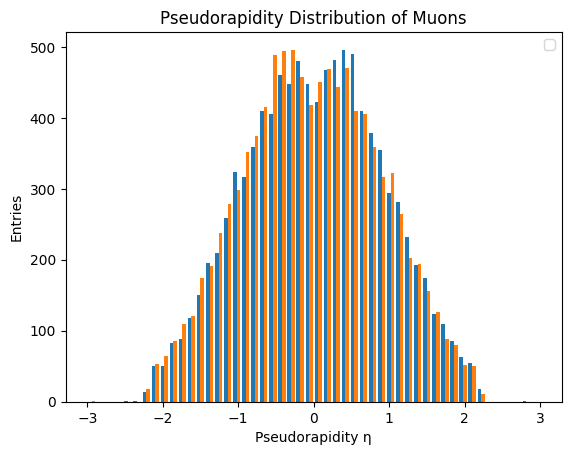

In [9]:
plt.hist(muons_v4.eta, bins=50, range=(-3, 3))
plt.xlabel('Pseudorapidity η')
plt.ylabel('Entries')
plt.title('Pseudorapidity Distribution of Muons')
plt.legend()
plt.show()

In [10]:
muons_v4.pt

<Array [[32.4, 32.4], [...], ..., [44.9, 45.3]] type='10000 * var * float64'>

In [11]:
order = ak.argsort(muons_pT, axis=1, ascending=False)

In [12]:
sorted_muons_pT = muons_pT[order]
sorted_muons_px = muons_px[order]
sorted_muons_py = muons_py[order]
sorted_muons_pz = muons_pz[order]
sorted_mouns_E = mouns_E[order]

In [13]:
leading_muons_pT = ak.fill_none(sorted_muons_pT[:, 0], 0)
subleading_muons_pT = ak.fill_none(sorted_muons_pT[:, 1], 0)

In [14]:
bins = np.linspace(0, 50, 100)

In [15]:
hist_leading, bin_edges = np.histogram(leading_muons_pT, bins=bins)
hist_subleading, bin_edges = np.histogram(subleading_muons_pT, bins=bins)

In [16]:
integral_leading = np.sum(hist_leading)
integral_subleading = np.sum(hist_subleading)

In [17]:
sigma_pb = 2.0129e3
n_events = tree.num_entries
lumi_pb = 1 # 1/fb = 1e3/pb
weights = (sigma_pb * lumi_pb) / n_events
#invariant_mass = ak.to_numpy(dimuon_events.mass)



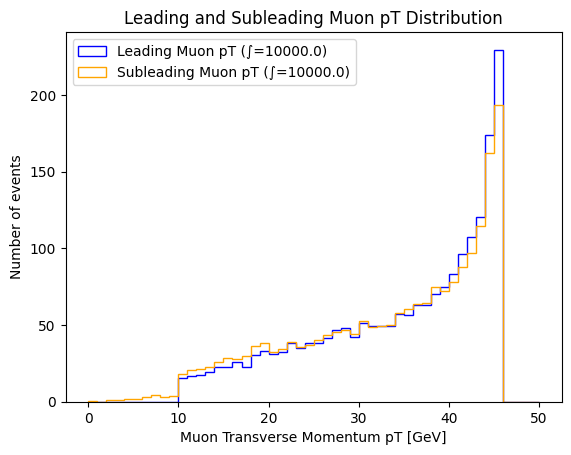

In [18]:
plt.hist(leading_muons_pT, bins=50, range=(0, 50), weights=np.full(len(leading_muons_pT), weights), label=f'Leading Muon pT (∫={integral_leading})', histtype='step', color='blue')
plt.hist(subleading_muons_pT, bins=50, range=(0, 50), weights=np.full(len(subleading_muons_pT), weights), label=f'Subleading Muon pT (∫={integral_subleading})', histtype='step', color='orange')
plt.xlabel('Muon Transverse Momentum pT [GeV]')
plt.ylabel('Number of events')
plt.title('Leading and Subleading Muon pT Distribution')
plt.legend()
plt.show()

In [19]:
leading_mouns_pT_np = ak.to_numpy(leading_muons_pT[~ak.is_none(leading_muons_pT)])
subleading_mouns_pT_np = ak.to_numpy(subleading_muons_pT[~ak.is_none(subleading_muons_pT)])

In [20]:
mask = ak.num(sorted_muons_pT, ) >= 2

In [21]:
two_muons_v4 = muons_v4[mask]
two_muons_v4

<MomentumArray4D [[{x: 16.5, y: -27.9, ...}, ...], ...] type='10000 * var *...'>

In [22]:
first_muons_v4 = two_muons_v4[:, 0]
second_muons_v4 = two_muons_v4[:, 1]

In [23]:
first_muons_v4.deltaR(second_muons_v4)

<Array [3.59, 4.35, 3.21, 3.16, ..., 3.98, 3.25, 3.15] type='10000 * float64'>

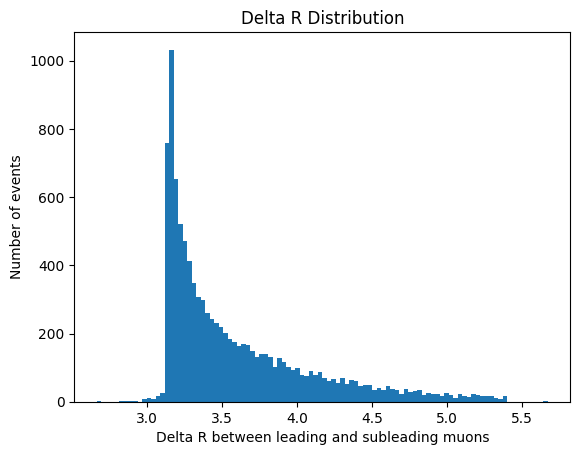

In [24]:
plt.hist(first_muons_v4.deltaR(second_muons_v4), bins=100)
plt.xlabel('Delta R between leading and subleading muons')
plt.ylabel('Number of events')
#plt.yscale('log')
plt.title('Delta R Distribution')
#plt.grid()
plt.show()

In [25]:
sum_v4 = first_muons_v4 + second_muons_v4

In [26]:
two_muons_charges = two_muons_v4.charge[mask]
opposite_charge_mask = two_muons_charges[:, 0] != two_muons_charges[:, 1] 

In [27]:
dimuon_events = sum_v4[opposite_charge_mask]

In [28]:
sigma_pb = 2.0129e3
n_events = tree.num_entries
lumi_pb = 1 # 1/fb = 1e3/pb
weights = (sigma_pb * lumi_pb) / n_events
invariant_mass = ak.to_numpy(dimuon_events.mass)



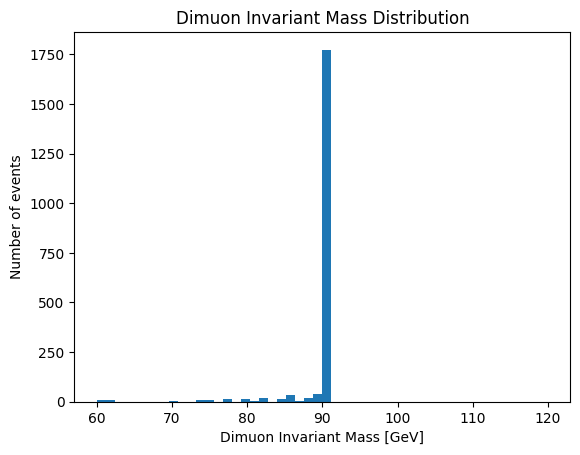

In [29]:
plt.hist(invariant_mass, bins=50, range=(60, 120), weights=np.full(len(invariant_mass), weights))   
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Dimuon Invariant Mass [GeV]')
plt.ylabel('Number of events')
plt.title('Dimuon Invariant Mass Distribution')
#plt.grid()
plt.show()

In [30]:
muons_px1, muons_py1, muons_pz1, muons_E1 = sorted_muons_px[mask][:, 0], sorted_muons_py[mask][:, 0], sorted_muons_pz[mask][:, 0], sorted_mouns_E[mask][:, 0]
muons_px2, muons_py2, muons_pz2, muons_E2 = sorted_muons_px[mask][:, 1], sorted_muons_py[mask][:, 1], sorted_muons_pz[mask][:, 1], sorted_mouns_E[mask][:, 1]

In [31]:
muons_px_pair = muons_px1 + muons_px2
muons_py_pair = muons_py1 + muons_py2
muons_pz_pair = muons_pz1 + muons_pz2
muons_E_pair = muons_E1 + muons_E2

In [32]:
m2 = muons_E_pair**2 - (muons_px_pair**2 + muons_py_pair**2 + muons_pz_pair**2)
m2 = ak.where(m2 < 0, 0, m2) # Remove negative values due to numerical precision
invariant_mass = np.sqrt(m2)

In [33]:
p1 = np.sqrt(muons_px1**2 + muons_py1**2 + muons_pz1**2)
p2 = np.sqrt(muons_px2**2 + muons_py2**2 + muons_pz2**2)

In [34]:
eta1 = 0.5 * np.log((p1 + muons_pz1) / (p1 - muons_pz1))
eta2 = 0.5 * np.log((p2 + muons_pz2) / (p2 - muons_pz2))

In [35]:
phi1 = np.arctan2(muons_py1, muons_px1)
phi2 = np.arctan2(muons_py2, muons_px2)

In [36]:
deta = eta1 - eta2
dphi = phi1 - phi2
dphi = (dphi + np.pi) % (2 * np.pi) - np.pi  # Wrap dphi to the range [-π, π]

In [37]:
deltaR = np.sqrt(deta**2 + dphi**2)

In [38]:
#_inv_np = ak.to_numpy(invariant_mass[~ak.is_none(invariant_mass)])

In [39]:
sigma_pb = 2.0129e3
n_events = tree.num_entries
weight = sigma_pb / n_events


In [40]:
weights_leading = np.full_like(leading_mouns_pT_np, weight)
weights_subleading = np.full_like(subleading_mouns_pT_np, weight)
weights_invariant = np.full_like(ak.to_numpy(invariant_mass), weight)

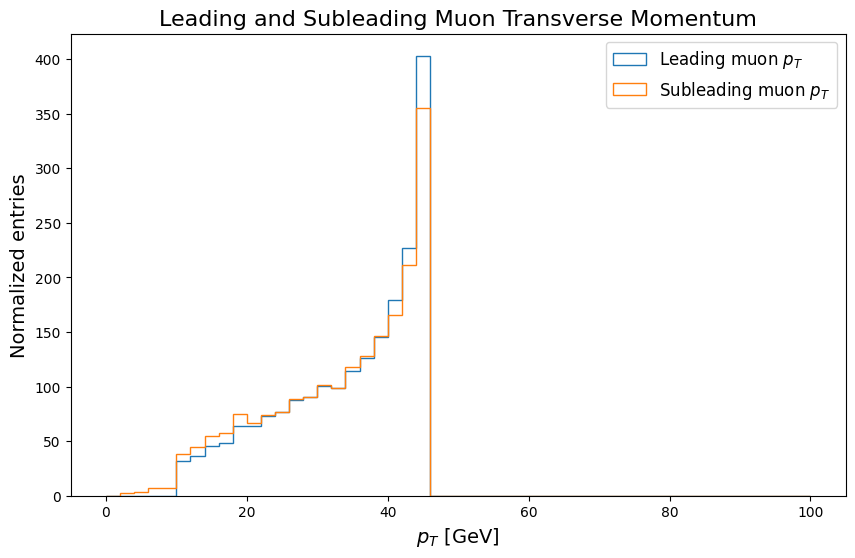

In [41]:
plt.figure(figsize=(10,6))
plt.hist(leading_mouns_pT_np, bins=50, range=(0, 100), histtype='step', label='Leading muon $p_T$', weights=weights_leading)
plt.hist(subleading_mouns_pT_np, bins=50, range=(0, 100), histtype='step', label='Subleading muon $p_T$', weights=weights_subleading)
plt.xlabel('$p_T$ [GeV]', fontsize=14)
plt.ylabel('Normalized entries', fontsize=14)
plt.title('Leading and Subleading Muon Transverse Momentum', fontsize=16)
plt.legend(fontsize=12)
#lt.grid()
plt.savefig("leading_subleading_muon_pT_normalized.png")
plt.show()  

In [ ]:
import os, matplotlib.pyplot as plt
OUT_DIR = "/web/omunkombwe/public_html"
os.makedirs(OUT_DIR, exist_ok=True)
nb = "normalized"
nums = plt.get_fignums()
for i, num in enumerate(nums, 1):
    fig = plt.figure(num)
    fname = f"{nb}_fig{i}.png"
    fig.savefig(fname, dpi=150)
print(f"Saved {len(nums)} figure(s) to {OUT_DIR}")
